In [1]:
import sys
sys.path.append('.')  

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

from preprocessing import run_full_pipeline, TOP_NUMERIC
from models import get_base_models, train_models, tune_all_models
from evaluation import (
    lasso_important_features, tree_feature_importance, rfe_selected_features,
    evaluate_models, plot_rmse_comparison
)

## 1. Preprocessing & Feature Engineering

In [2]:
X_scaled, X_poly, y, scaler = run_full_pipeline('../data/raw/train.csv')

print("X_scaled shape:", X_scaled.shape)
print("X_poly shape:  ", X_poly.shape)

X_scaled shape: (1458, 262)
X_poly shape:   (1458, 272)


## 2. Data Splitting

In [3]:
# Split scaled features into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
# Separate split for Polynomial Regression using polynomial features
X_train_poly, X_test_poly, y_train_poly, y_test_poly = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

## 3. Model Implementation & Training

In [4]:
models = get_base_models()

# Train Polynomial Regression separately on the poly features
models['Polynomial Regression'].fit(X_train_poly, y_train_poly)

# Train the rest on the regular scaled features
other_models = {k: v for k, v in models.items() if k != 'Polynomial Regression'}
trained_models = train_models(other_models, X_train, y_train)
trained_models['Polynomial Regression'] = models['Polynomial Regression']

## 4. Feature Selection

In [5]:
# Method 1 — Lasso coefficients
important_lasso = lasso_important_features(trained_models['Lasso Regression'], X_train)
print(important_lasso.head(15))

GrLivArea               0.078489
TotalSF                 0.068211
HouseAge               -0.059591
OverallQual             0.056235
OverallCond             0.039813
SaleType_New            0.031811
BsmtFinSF1              0.025115
SaleCondition_Normal    0.023468
Neighborhood_Crawfor    0.022968
LotArea                 0.022818
MSZoning_RL             0.020169
Condition1_Norm         0.020005
GarageArea              0.019047
RemodAge               -0.018645
Neighborhood_StoneBr    0.018540
dtype: float64


In [6]:
# Method 2 — feature importances from tree models
rf_importance = tree_feature_importance(trained_models['Random Forest'], X_train)
xgb_importance = tree_feature_importance(trained_models['XGBoost'], X_train)
print(rf_importance.head(15))
print(xgb_importance.head(15))

OverallQual     0.389945
TotalSF         0.370065
GarageArea      0.015560
GarageCars      0.015114
CentralAir_Y    0.013259
TotalBath       0.012036
LotArea         0.011914
GrLivArea       0.011592
BsmtFinSF1      0.009684
RemodAge        0.009655
HouseAge        0.008845
GarageYrBlt     0.008218
YearBuilt       0.007239
BsmtUnfSF       0.006732
OverallCond     0.006433
dtype: float64
OverallQual             0.192951
CentralAir_Y            0.180625
TotalSF                 0.166350
GarageType_Detchd       0.061863
GarageCars              0.048325
LandSlope_Mod           0.032587
KitchenAbvGr            0.021667
KitchenQual_Gd          0.020481
MSZoning_RM             0.018532
Neighborhood_Crawfor    0.012905
BsmtExposure_Gd         0.012770
Fireplaces              0.010751
TotalBath               0.010563
GarageQual_TA           0.010236
RemodAge                0.008906
dtype: float32


In [7]:
# Method 3 — Recursive Feature Elimination (on Ridge)
selected_features = rfe_selected_features(X_train, y_train, n_features=20)
print(selected_features.tolist())

['OverallQual', 'OverallCond', 'BsmtFinSF1', '1stFlrSF', '2ndFlrSF', 'GrLivArea', 'Fireplaces', 'GarageArea', 'PoolArea', 'MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Foundation_PConc', 'PoolQC_None', 'SaleType_New', 'SaleCondition_Normal', 'SaleCondition_Partial', 'HouseAge', 'TotalSF']


## 5. Hyperparameter Tuning

In [8]:
tuned = tune_all_models(X_train, y_train)

# Swap in the tuned estimators (Polynomial Regression has no hyperparameters to tune)
trained_models.update(tuned)

Best Ridge alpha: {'alpha': 100}
Best Lasso alpha: {'alpha': 0.001}
Best RF params: {'n_estimators': 600, 'min_samples_split': 2, 'max_features': 'sqrt', 'max_depth': 30}
Best XGBoost params: {'subsample': 0.7, 'n_estimators': 600, 'max_depth': 3, 'learning_rate': 0.05}


## 6. Model Evaluation

In [9]:
results_df = evaluate_models(trained_models, X_test, X_test_poly, y_test)
results_df

,Model,MSE,RMSE,MAE,R2
0,XGBoost,3.767939e+08,19411.179181,13964.888699,0.931786
1,Lasso Regression,4.333311e+08,20816.606377,14618.963712,0.921551
2,Ridge Regression,4.839120e+08,21997.999154,15440.103300,0.912394
3,Polynomial Regression,4.973275e+08,22300.840757,15426.719779,0.909965
4,Random Forest,5.851904e+08,24190.708928,16402.695056,0.894059


## 7. Model Comparison

FileNotFoundError: [Errno 2] No such file or directory: '../visualizations/model_comparison_rmse.png'

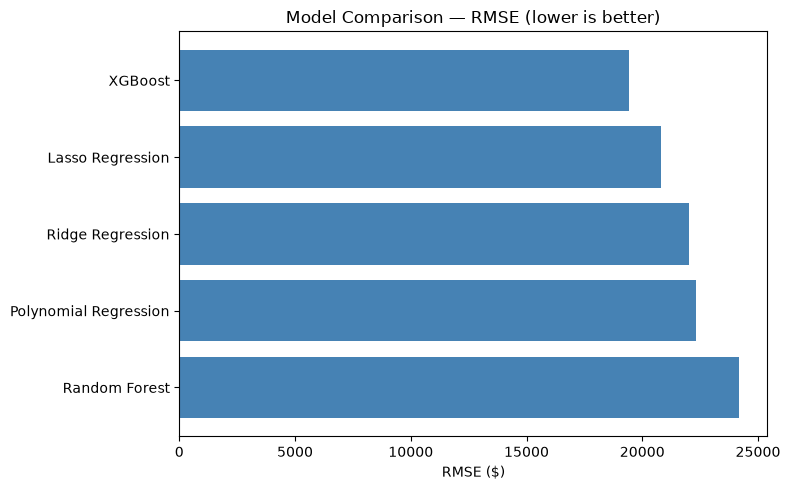

In [10]:

plot_rmse_comparison(
    results_df,
    save_path="../visualizations/model_comparison_rmse.png"
)

In [ ]:
from pathlib import Path
import pickle

# Create artifacts folder inside web app folder
ARTIFACT_DIR = Path("../Module_5_Web_App/artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# Select best model based on RMSE
best_model_name = results_df.iloc[0]["Model"]

# If Polynomial Regression wins, use best non-polynomial model for simple app
if best_model_name == "Polynomial Regression":
    print("Polynomial Regression performed best, but the web app currently supports non-polynomial models only.")
    best_model_name = results_df[results_df["Model"] != "Polynomial Regression"].iloc[0]["Model"]

best_model = trained_models[best_model_name]

print("Selected model for web app:", best_model_name)

# Convert scaled X_train back to original pre-scaled feature values
X_train_unscaled = pd.DataFrame(
    scaler.inverse_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Save realistic default values in ORIGINAL scale, not scaled scale
default_values = X_train_unscaled.median(numeric_only=True).to_dict()

# For one-hot encoded columns, use mode
for col in X_train_unscaled.columns:
    unique_vals = set(np.round(X_train_unscaled[col].dropna().unique(), 6))
    if unique_vals <= {0, 1}:
        default_values[col] = X_train_unscaled[col].mode().iloc[0]

# Save artifacts
with open(ARTIFACT_DIR / "best_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open(ARTIFACT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(ARTIFACT_DIR / "feature_columns.pkl", "wb") as f:
    pickle.dump(X_train.columns.tolist(), f)

with open(ARTIFACT_DIR / "default_values.pkl", "wb") as f:
    pickle.dump(default_values, f)

with open(ARTIFACT_DIR / "best_model_name.pkl", "wb") as f:
    pickle.dump(best_model_name, f)

# Save model results
results_df.to_csv(ARTIFACT_DIR / "model_results.csv", index=False)

print("Artifacts saved successfully.")

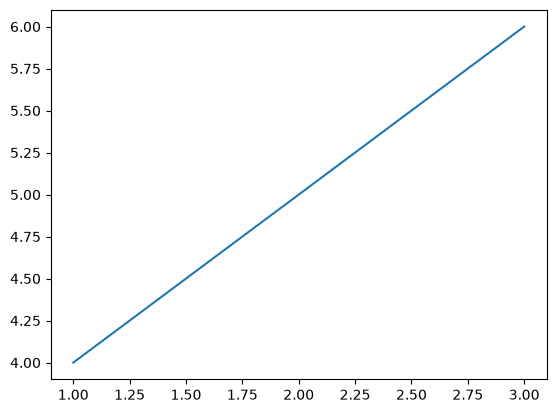

In [13]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot([1, 2, 3], [4, 5, 6])
plt.savefig("visualizations/test.png")
plt.show()
